In [11]:
import sys
from datetime import datetime
import tracemalloc
import pdb
import os
import ipynbname
import gc
import glob
import ast
import traceback
import time
import shutil

#math
import math
import re
import itertools
import ast
import csv
import numpy as np
import pandas as pd
import seaborn as sns
import collections
from collections import Counter, defaultdict

#JSON output
import json
import IPython
from IPython.display import display, JSON

#graph
import networkx as nx
from graphviz import Digraph
from IPython.display import display, JSON
from scipy import stats

#plots
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.image as mpimg
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

#packages for Persistence Topology analysis
import plotly.tools as tls
import plotly.graph_objects as go
import plotly.io as pio
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from gudhi import RipsComplex, SimplexTree
from gudhi.wasserstein import wasserstein_distance
import gudhi

print('sys verson = ' + sys.version)
print('IPython verson = ' + IPython.__version__)

%matplotlib inline
my_client = fbl.get_client()

sys verson = 3.9.16 | packaged by conda-forge | (main, Feb  1 2023, 21:39:03) 
[GCC 11.3.0]
IPython verson = 8.14.0


In [14]:
data = my_client.executeNLPquery('clear')

[FBL NLP 2026-04-22 23:55:56,021] NLP successfully parsed query.


In [15]:
#Neurmorphology and Simulation
import neuroarch.na as na
dbDataset = na.NeuroArch("hemibrain",port=2424) #create connection to flywire

In [16]:
import neuroarch.version
print(neuroarch.version.__version__)

0.4.3


In [13]:
#turn on breakpoints?
%pdb on

Automatic pdb calling has been turned ON


# Github

In [11]:
!git init
!git remote add origin https://github.com/sgarnell/archive

Reinitialized existing Git repository in /home/ffbo/ffbo/.git/
fatal: remote origin already exists.


In [12]:
!git remote -v

origin	https://github.com/sgarnell/archive.git (fetch)
origin	https://github.com/sgarnell/archive.git (push)


In [11]:
# Stage the notebook file
!git add 'ephaptic_coupling_v1.ipynb'

# Commit the changes
!git commit -m "Auto commit from Jupyter for {notebook_name}"

# Push to GitHub
!git push origin fbl2-main

[fbl2-main ba31994] Auto commit from Jupyter for {notebook_name}
 1 file changed, 798 insertions(+), 539 deletions(-)
Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 16 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 385.65 KiB | 1.91 MiB/s, done.
Total 3 (delta 2), reused 0 (delta 0)
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/sgarnell/archive.git
   da6a0c4..ba31994  fbl2-main -> fbl2-main


# Initialize

# Optional

In [13]:
# Query to retrieve sample records from the Neuropil class
query = "SELECT * FROM MetaData LIMIT 100"  # Adjust the limit as needed
metadata_records = dbDataset.sql_query(query)


if len(metadata_records) == 0:
    print("No records found in the 'metaData' class.")
else:
    print("Sample records in 'metaData' class:")
    for record in metadata_records:
        # Print the ID and the properties of each record
        print(f"version: {record.version}, registryname: {  record.props }")
        #print(str(record.))
        # Synonyms: {record.get_props['synonyms']}


Sample records in 'metaData' class:
version: 2.0.1, registryname: {'created_by': {'min_NeuroArch_version_supported': '0.4.1', 'created_date': '2022-06-18T02:10:08.724498', 'NeuroArch_version': '0.4.0', 'OrientDB_version': '3.1.17'}, 'maintainer': {'name': 'Yiyin Zhou', 'email': 'yiyin@ee.columbia.edu'}, 'version': '2.0.1'}


In [14]:
# Query to retrieve all class types in the OrientDB database
query = "SELECT name FROM (SELECT expand(classes) FROM metadata:schema)"
class_types = dbDataset.sql_query(query)

if len(class_types) == 0:
    print("No class types found in the database.")
else:
    # Store class names in a list
    class_names = [class_type.name for class_type in class_types]

    # Sort the list alphabetically
    sorted_class_names = sorted(class_names)

    # Print the sorted list
    for class_name in sorted_class_names:
        print(class_name)


Aggregator
AlphaSynapse
ArborizationData
ArborizesIn
AxonHillockModel
BioNode
BioSensor
BufferPhoton
BufferVoltage
CRModel
Cartridge
CartridgeModel
Circuit
CircuitDiagram
CircuitModel
Column
ColumnModel
DataSource
DendriteModel
DesignNode
E
ExecutableCircuit
GapJunction
GeneticData
Glomerulus
HasData
HasQueryResults
HodgkinHuxley
HodgkinHuxleyFull
InferredSynapse
Interface
LPU
LeakyIAF
LeakyIAFwithRefractoryPeriod
MembraneModel
MetaData
Models
MorphologyData
MorrisLecar
NarxAdaptive
Neuron
NeuronAndFragment
NeuronFragment
NeuronModel
NeuronTerminal
Neuropil
NeurotransmitterData
Node
OFunction
OGeometryCollection
OIdentity
OLineString
OMultiLineString
OMultiPoint
OMultiPolygon
OPoint
OPolygon
ORectangle
ORestricted
ORole
OSchedule
OSecurityPolicy
OSequence
OShape
OTriggered
OUser
Ommatidium
OmmatidiumModel
Owns
Pattern
PhotoreceptorCell
PhotoreceptorModel
Port
PowerGPotGPot
QueryOwns
QueryResult
Relationship
Requires
SendsTo
SigmoidSynapse
Species
Subregion
Subsystem
Synapse
SynapseAMPA

In [15]:
####Total Schema #######
def get_class_metadata(className, client, visited=None):

    tempMetaData = {}
    # Query to retrieve sample records from the Neuropil class
    query = f"SELECT * FROM {className} LIMIT 1"  # Adjust the limit as needed
    class_records = client.sql_query(query)
    for record in class_records:
        tempMetaData[className] = str(record._props)
    #print(f"ID: {record._id}, Name: {record._props['name']}, Synonyms: {record._props['synonyms']}")
    
    if not tempMetaData:
        return {}

    return tempMetaData

def get_full_metadata(client):
    
    #clear dicts
    metadata_dict = {}
    query = "SELECT name FROM (SELECT expand(classes) FROM metadata:schema)"
    class_types = client.sql_query(query)
    #list of names
    class_names = [class_type.name for class_type in class_types]
    for className in class_names:
        classProps = get_class_metadata(className, client)
        metadata_dict[className] = classProps
    return metadata_dict #return dict

# Connect to the database

# Get metadata and save to JSON
metadata_dict = get_full_metadata(dbDataset)

with open("metadata_tree.json", "w") as f:
    json.dump(metadata_dict, f, indent=4)

print("Metadata saved to metadata_tree.json")


Metadata saved to metadata_tree.json


In [16]:


# Query to retrieve sample records from the Neuropil class
query = "SELECT * FROM Neuropil LIMIT 100"  # Adjust the limit as needed
neuropil_records = dbDataset.sql_query(query)

if len(neuropil_records) == 0:
    print("No records found in the 'Neuropil' class.")
else:
    print("Sample records in 'Neuropil' class:")
    for record in neuropil_records:
        # Print the ID and the properties of each record
        print(f"ID: {record._id}, Name: {record._props['name']}, Synonyms: {record._props['synonyms']}")


Sample records in 'Neuropil' class:
ID: #394:0, Name: MB(R), Synonyms: None
ID: #430:0, Name: AVLP(R), Synonyms: None
ID: #433:0, Name: SCL(L), Synonyms: None
ID: #432:0, Name: SCL(R), Synonyms: None
ID: #398:1, Name: AB(L), Synonyms: None
ID: #419:0, Name: ATL(L), Synonyms: None
ID: #426:0, Name: FB, Synonyms: None
ID: #399:0, Name: GNG, Synonyms: None
ID: #401:0, Name: AME(R), Synonyms: None
ID: #400:0, Name: ME(R), Synonyms: None
ID: #412:0, Name: SIP(L), Synonyms: None
ID: #424:0, Name: LO(R), Synonyms: None
ID: #397:1, Name: AB(R), Synonyms: None
ID: #417:0, Name: IB, Synonyms: None
ID: #408:0, Name: PLP(R), Synonyms: None
ID: #407:0, Name: AOTU(R), Synonyms: None
ID: #395:1, Name: SPS(L), Synonyms: None
ID: #404:0, Name: BU(L), Synonyms: None
ID: #409:0, Name: WED(R), Synonyms: None
ID: #423:0, Name: PRW, Synonyms: None
ID: #437:0, Name: VES(L), Synonyms: None
ID: #395:0, Name: MB(L), Synonyms: None
ID: #414:0, Name: SMP(L), Synonyms: None
ID: #418:0, Name: ATL(R), Synonyms: None

# Get Neurons within the Neuropil of interest.

## This cell provides:
 - a clean list of all FB neurons
- a reproducible starting point
- a foundation for filtering by layer

In [17]:

# --- Step 1: Select the FB neuropil ---
FB = dbDataset.sql_query('SELECT FROM Neuropil WHERE name = "FB"')

# --- Step 2: Get all neurons that arborize in the FB ---
fb_neurons = FB.gen_traversal_in(['ArborizesIn', 'Neuron'], min_depth=1)

# --- Step 3: Extract unique cell types ---
celltypes = sorted({n.name for n in fb_neurons.node_objs})
print(f"Found {len(celltypes)} FB-innervating cell types")

# --- Step 4: Preview a few ---
for n in itertools.islice(fb_neurons.node_objs, 50):
    print(n.props['name'])


Found 299 FB-innervating cell types
PFNp_b
vDeltaC
FB6J
PEG
FB8H
SMP601
vDeltaA_a
vDeltaA_a
FC1A
PFNp_d
PFNp_b
FB6N
FB8A
PFNp_d
FC2A
FB5V
vDeltaI
PFNd
FR2
hDeltaJ
FC1F
PFNp_b
hDeltaC
FB5V
AVLP115
FB5G
vDeltaA_a
PFNp_b
hDeltaB
hDeltaF
vDeltaL
vDeltaA_a
FS3
EL
vDeltaB
PFNp_b
PFNm_a
FC1B
FB5W
PFNp_a
FB8F_b
vDeltaA_b
hDeltaJ
PFNa
FS4A
vDeltaB
FS4B
hDeltaC
FB6V
PFNp_b


In [18]:
#Supporting routine to locate post and pre synapses

def locate_psd(q, prob = 0.0, cell_type = False, travIn = True):
    
    if travIn == True:
        prepost_synapse_morph  = q.gen_traversal_in(
                                ['SendsTo', 'Synapse'],
                                min_depth = 1).gen_traversal_out(
                                ['HasData', 'MorphologyData'],
                                min_depth = 1)
    else:
         prepost_synapse_morph  = q.gen_traversal_out(
                                ['SendsTo', 'Synapse'],
                                ['HasData', 'MorphologyData'],
                                min_depth = 2)
    
    x = []
    y = []
    z = []
    names = []
    neuron_ind = []
    for i, n in enumerate(prepost_synapse_morph):
        
        # pre = presynaptic_neuron_uname(n.uname)
        if travIn == True:
            synName = n.uname.split('--',1)[0]
        else:
            synName = n.uname.split('--',1)[1]
            
        names.append(synName)
        n_syn = len(n.x)//2
        try:
            if len(n.confidence):
                conf = [a >= prob and b >= prob for a, b in zip(n.confidence[:n_syn], n.confidence[n_syn:])]
            elif len(n.confidence) == n_syn:
                conf = [a >= prob for a in n.confidence]
            else:
                raise ValueError()
            x.extend([v for v, c in zip(n.x[n_syn:], conf) if c])
            y.extend([v for v, c in zip(n.y[n_syn:], conf) if c])
            z.extend([v for v, c in zip(n.z[n_syn:], conf) if c])
            neuron_ind.extend([i] * sum(conf))
        except:
            x.extend(n.x[n_syn:])
            y.extend(n.y[n_syn:])
            z.extend(n.z[n_syn:])
            neuron_ind.extend([i] * n_syn)
    psd = {(x[i], y[i], z[i]): names[neuron_ind[i]] for i in range(len(x))}
    return psd

In [19]:
print(type(fb_neurons))
print(type(fb_neurons.node_objs[0]))
n = fb_neurons.node_objs[0]
print("---Neuron Data---")
print("Neuron object:", n)
print("Properties:", n.props)
print("Attributes:", dir(n))
print("---Synapse Data---")
# Pick any neuron that arborizes in the FB

n = fb_neurons.node_objs[0]
q = fb_neurons.from_objs(dbDataset.graph, [n])

psds = locate_psd(q, travIn=True)

# Now inspect one morphology object directly
syn = q.gen_traversal_in(['SendsTo', 'Synapse'], min_depth=1)
syn_morph = syn.gen_traversal_out(['HasData', 'MorphologyData'], min_depth=1)

print(syn_morph.node_objs[0]._props)






<class 'neuroarch.query.QueryWrapper'>
<class 'neuroarch.models.Neuron'>
---Neuron Data---
Neuron object: <neuroarch.models.Neuron object at 0x7fc2935bbf40>
Properties: {'info': {'Hemibrain Trace Status': 'Roughly traced'}, 'label': None, 'locality': None, 'name': 'PFNp_b', 'referenceId': '633200987', 'synonyms': None, 'uname': 'PFNp_b(PB01b)_R4_C7_8'}
Attributes: ['Abstract', 'Broker', 'PropertyLookup', '__call__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_graph', '_id', '_props', 'both', 'bothE', 'context', 'decl_root', 'decl_type', 'element_plural', 'element_type', 'from_graph', 'get_props', 'gremlin', 'gremlin_raw', 'inE', 'in_', 'info', 'label', 'load', 'locality', 'name', 'objects'

In [20]:
def get_fb_layer_neurons(layer_number):
    """
    Returns all neurons whose celltype name begins with FB{layer_number}.
    Example: layer_number=1 → FB1A, FB1B, FB1G, etc.
    """
    prefix = f"FB{layer_number}"
    q = dbDataset.sql_query(
        f'SELECT FROM Neuron WHERE name LIKE "{prefix}%"'
    )
    return q.node_objs

fb1_neurons = get_fb_layer_neurons(1)
for n in fb1_neurons:
    print(n.props['uname'])



FB1G_L_1
FB1I_R_1
FB1A_R_1
FB1I_L_1
FB1J_R_1
FB1C(NO1/NO3)_R_2
FB1E_b_R_1
FB1E_a_L_1
FB1E_a_R_2
FB1C(NO1/NO3)_L_2
FB1H(NO2/3)_R_1
FB1A_L_2
FB1J_L_1
FB1A_R_2
FB1D_L_2
FB1D_R_2
FB1H(NO2/3)_L_1
FB1E_b_L_1
FB1D_L_1
FB1B_R_2
FB1C(NO1/NO3)_R_1
FB1B_L_1
FB1F_R_1
FB1G_R_1
FB1B_L_2
FB1E_a_L_2
FB1A_L_1
FB1C(NO1/NO3)_L_1
FB1E_a_R_1
FB1D_R_1
FB1F_L_1
FB1B_R_1


In [56]:
#Get synapses and point clouds for each layer

def extract_synapse_points(morph_obj, prob=0.0):
    """
    Extracts (x,y,z) synapse coordinates from a MorphologyData object.
    Applies confidence filtering if available.
    Returns a list of (x,y,z) tuples.
    """
    points = []
    n_syn = len(morph_obj.x) // 2

    # Confidence filtering
    if hasattr(morph_obj, "confidence") and len(morph_obj.confidence) > 0:
        if len(morph_obj.confidence) == 2 * n_syn:
            conf = [a >= prob and b >= prob
                    for a, b in zip(morph_obj.confidence[:n_syn],
                                    morph_obj.confidence[n_syn:])]
        else:
            conf = [c >= prob for c in morph_obj.confidence]
    else:
        conf = [True] * n_syn

    # Extract post-synaptic coordinates
    xs = morph_obj.x[n_syn:]
    ys = morph_obj.y[n_syn:]
    zs = morph_obj.z[n_syn:]

    for x, y, z, c in zip(xs, ys, zs, conf):
        if c:
            points.append((x, y, z))

    return points



def get_layer_pointcloud(layer_number, incoming=True, max_neurons=None, prob=0.0, gc_every=5):
    """
    Extracts a full point cloud of synapses for all neurons in FB layer N.
    Also returns a dict counting synapses per incoming neuron cell type.
    Performs aggressive memory cleanup after each neuron.
    """

    prefix = f"FB{layer_number}"
    q = dbDataset.sql_query(f'SELECT FROM Neuron WHERE name LIKE "{prefix}%"')
    neurons = q.node_objs

    if max_neurons is not None:
        neurons = neurons[:max_neurons]

    all_points = []
    synapse_counts = defaultdict(int)

    print(f"\n=== Processing FB Layer {layer_number} ===")
    print(f"Found {len(neurons)} neurons matching prefix {prefix}\n")

    for idx, neuron in enumerate(neurons):

        print(f"[{idx+1}/{len(neurons)}] Neuron: {neuron.props['uname']}")

        # Wrap neuron in traversal object
        nq = q.from_objs(dbDataset.graph, [neuron])

        # Incoming or outgoing synapses
        if incoming:
            syn = nq.gen_traversal_in(['SendsTo', 'Synapse'], min_depth=1)
        else:
            syn = nq.gen_traversal_out(['SendsTo', 'Synapse'], min_depth=1)

        syn_morph = syn.gen_traversal_out(['HasData', 'MorphologyData'], min_depth=1)

        # Extract coordinates + count per presynaptic cell type
        for morph_obj in syn_morph.node_objs:

            pts = extract_synapse_points(morph_obj, prob=prob)
            all_points.extend(pts)

            try:
                pre_name = morph_obj.uname.split("--")[0]
            except:
                pre_name = "UNKNOWN"

            synapse_counts[pre_name] += len(pts)

        # --- MEMORY CLEANUP SECTION ---
        del syn_morph
        del syn
        del nq

        # Optional: free memory every N neurons
        if (idx + 1) % gc_every == 0:
            gc.collect()

    # Sort counts
    sorted_counts = dict(sorted(synapse_counts.items(), key=lambda x: x[1], reverse=True))

    print("\n=== Synapse Counts by Incoming Neuron Type ===")
    for name, count in list(sorted_counts.items())[:20]:
        print(f"{name:30s}  {count}")

    print(f"\nTotal synapses in layer {layer_number}: {len(all_points)}\n")

    # Final cleanup
    gc.collect()

    return all_points, sorted_counts



In [ ]:

fb5_points, fb5_sources = get_layer_pointcloud(5, incoming=True)
print(f"FB5 synapse count: {len(fb5_points)}")

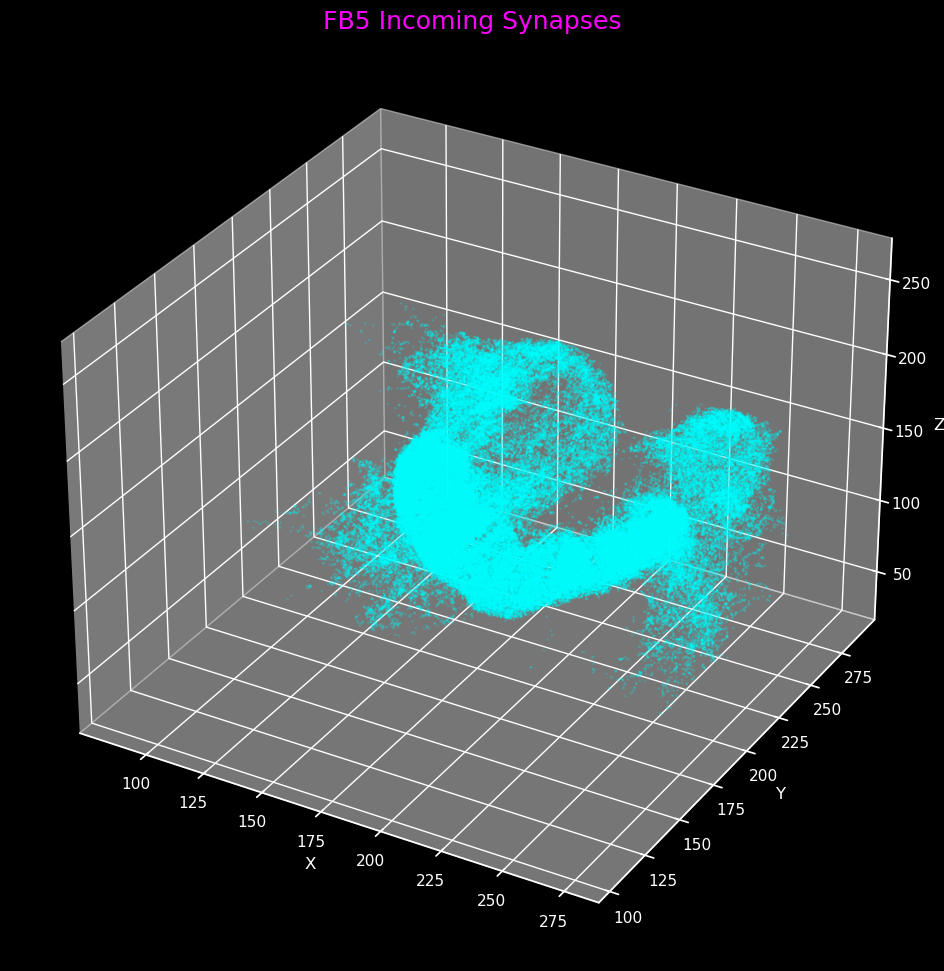

In [20]:
def visualize_layer_pointcloud(points, title="FB Layer", color="cyan", alpha=0.3, s=1):
    """
    Simple, fast 3D scatter for large FB layer point clouds.
    points: list of (x,y,z)
    """

    pts = np.array(points)
    x, y, z = pts[:,0], pts[:,1], pts[:,2]

    fig = plt.figure(figsize=(12,12))
    ax = fig.add_subplot(111, projection='3d')

    ax.set_facecolor("black")
    fig.patch.set_facecolor("black")

    ax.scatter(x, y, z, s=s, c=color, alpha=alpha)

    ax.set_xlabel("X", color="white")
    ax.set_ylabel("Y", color="white")
    ax.set_zlabel("Z", color="white")

    ax.tick_params(colors="white")
    plt.title(title, color="magenta", fontsize=18)

    plt.show()
    
visualize_layer_pointcloud(
    fb5_points,
    title="FB5 Incoming Synapses",
    color="cyan",
    alpha=0.15,
    s=1
)


In [21]:
from IPython.display import clear_output
clear_output(wait=True)


def cleanup_memory():
    plt.close('all')   # close all matplotlib figures
    gc.collect()       # force Python garbage collection

cleanup_memory()

In [ ]:




def visualize_layer_plotly(points, title="FB Layer"):
    pts = np.array(points)
    x, y, z = pts[:,0], pts[:,1], pts[:,2]

    fig = go.Figure(data=[go.Scatter3d(
        x=x, y=y, z=z,
        mode='markers',
        marker=dict(
            size=3,        # <--- increase point size here
            opacity=0.4,
            color=z,
            colorscale='Viridis'
        )
    )])
    
    anterior_camera = dict(
    eye=dict(x=2, y=0, z=0),   # camera in front of the FB
    up=dict(x=0, y=1, z=1),         # z-axis is up
    center=dict(x=0, y=0, z=0) )


    fig.update_layout(
        scene_camera=anterior_camera,
        title=title,
        height=1000,       # <--- increase vertical height of the viewer
        width=1200,        # <--- optional: increase width too
        scene=dict(
            bgcolor="black",
            xaxis=dict(backgroundcolor="black", gridcolor="gray"),
            yaxis=dict(backgroundcolor="black", gridcolor="gray"),
            zaxis=dict(backgroundcolor="black", gridcolor="gray"),
        ),
        paper_bgcolor="black",
        font=dict(color="white")
    )

    fig.show()

def downsample_points(points, fraction=0.2):
    import random
    k = int(len(points) * fraction)
    return random.sample(points, k)

    
fb5_small = downsample_points(fb5_points, fraction=0.10)
visualize_layer_plotly(fb5_small)



# Data Export

In [41]:
import itertools
import time
from datetime import datetime

def build_global_fb_psd(incoming=True, prob=0.0, max_neurons=None, max_print=5):
    """
    Diagnostic version: prints detailed information while building the global PSD map.
    Includes timestamps and runtime measurement.
    """

    print("\n=== Building Global FB PSD Map ===")
    print(f"Incoming synapses: {incoming}")
    print(f"Confidence threshold: {prob}")
    print(f"Max neurons: {max_neurons}")
    print("----------------------------------")


    # Step 1: Get FB neurons
    FB = dbDataset.sql_query('SELECT FROM Neuropil WHERE name = "FB"')
    fb_neurons = FB.gen_traversal_in(['ArborizesIn', 'Neuron'], min_depth=1)

    total_neurons = len(fb_neurons.node_objs)
    print(f"Total FB-innervating neurons found: {total_neurons}")

    iterator = fb_neurons.node_objs
    if max_neurons is not None:
        iterator = itertools.islice(iterator, max_neurons)

    global_psd = {}
    neuron_counter = 0
    total_synapses = 0

    # Step 2: Loop through neurons
    current_print = 1
    

    for n in iterator:
        neuron_counter += 1

        # Wrap neuron into a traversal
        q = fb_neurons.from_objs(dbDataset.graph, [n])

        # Extract synapses
        psds = locate_psd(q, travIn=incoming, prob=prob)
        syn_count = len(psds)
        

        if current_print <= max_print:
            print(f"Ncounter: {neuron_counter} Name:  {n.uname} Synapse count: {syn_count} ")
            current_print += 1
        # --- Compact progress indicator after that ---
        else:
            # Green dot = synapses found
            # Red dot = zero synapses
            if neuron_counter % 10 == 0:
                dot = "\033[32m.\033[0m" if syn_count > 0 else "\033[31m.\033[0m"
                print(dot, end="", flush=True)

            # Block marker every 100 neurons
            if neuron_counter % 100 == 0:
                print(" | ", end="", flush=True)

            # Newline every 1000 neurons
            if neuron_counter % 1000 == 0:
                print(f"  ({neuron_counter})", flush=True)

        
        # Merge into global map
        global_psd.update(psds)
        total_synapses += syn_count


    # Final newline
    print("\n")
    print("\n=== Global PSD Build Complete ===")
    print(f"Neurons processed: {neuron_counter} Total Synapse: {total_synapses} PSD coords: {len(global_psd)} ")


    return global_psd


In [48]:
def save_global_psd(global_psd, filename="FB_incoming_all_synapses.npz"):
    coords = np.array(list(global_psd.keys()), dtype=np.float32)
    names = np.array(list(global_psd.values()), dtype=object)

    # Build neuron summary
    from collections import Counter
    counter = Counter(names)
    neuron_names = np.array(list(counter.keys()), dtype=object)
    counts_per_neuron = np.array(list(counter.values()), dtype=np.int32)

    # Bounds & centroid
    xmin, ymin, zmin = coords.min(axis=0)
    xmax, ymax, zmax = coords.max(axis=0)
    bounds = np.array([xmin, xmax, ymin, ymax, zmin, zmax], dtype=np.float32)
    centroid = coords.mean(axis=0).astype(np.float32)

    # Save using the SAME schema as layer files
    np.savez(
        filename,
        points=coords,
        pre_names=names,
        layer=np.full(len(coords), -1, dtype=np.int32),  # -1 = global, no layer
        bounds=bounds,
        centroid=centroid,
        neuron_names=neuron_names,
        counts_per_neuron=counts_per_neuron,
        density_grid=None,
        density_meta=None,
    )

    print(f"Saved global PSD file: {filename}")
    print(f"Total synapses: {len(coords)}")
    print(f"Unique neuron types: {len(neuron_names)}")




In [49]:
start_time = time.time()
print(f"Start time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
global_psd = build_global_fb_psd(incoming=True, max_neurons=None)

# End timing
end_time = time.time()
elapsed = end_time - start_time
print(f"Total time: {elapsed:.2f} seconds ({elapsed/60:.2f} minutes)")

save_global_psd(global_psd, filename="FB_incoming_all_synapses.npz")

Start time: 2026-04-23 03:53:41


=== Building Global FB PSD Map ===
Incoming synapses: True
Confidence threshold: 0.0
Max neurons: None
----------------------------------
Total FB-innervating neurons found: 2577
Ncounter: 1 Name:  PFNp_b(PB01b)_R4_C7_8 Synapse count: 191 
Ncounter: 2 Name:  vDeltaC_C7_1 Synapse count: 698 
Ncounter: 3 Name:  FB6J_L_1 Synapse count: 1392 
Ncounter: 4 Name:  PEG(PB07)_L8_1 Synapse count: 923 
Ncounter: 5 Name:  FB8H_R_1 Synapse count: 739 
.......... | .......... | .......... | .......... | .......... | .......... | .......... | .......... | .......... | .......... |   (1000)
.......... | .......... | .......... | .......... | .......... | .......... | .......... | .......... | .......... | .......... |   (2000)
.......... | .......... | .......... | .......... | .......... | .......


=== Global PSD Build Complete ===
Neurons processed: 2577 Total Synapse: 2952590 PSD coords: 2952590 
Total time: 434.86 seconds (7.25 minutes)
Saved global PSD file: FB_

In [45]:
def sanity_check_synapse_file(filename, neuron_type=None, first_n=10):
    print(f"\n=== Loading file: {filename} ===")
    data = np.load(filename, allow_pickle=True)

    points = data.get("points")
    pre_names = data.get("pre_names")
    layer = data.get("layer")
    bounds = data.get("bounds")
    centroid = data.get("centroid")
    neuron_names = data.get("neuron_names")
    counts_per_neuron = data.get("counts_per_neuron")

    print("\n--- File Summary ---")
    print(f"Total synapses: {len(points)}")
    if layer is not None and len(layer) > 0:
        if np.all(layer == -1):
            print("Layer: GLOBAL (all FB layers)")
        else:
            print(f"Layer index: {layer[0]}")

    print(f"Bounds: {bounds}")
    print(f"Centroid: {centroid}")

    # --- Limit presynaptic neuron summary ---
    print("\n--- Presynaptic Neuron Types (showing first", first_n, ") ---")

    # Sort by descending synapse count
    sorted_pairs = sorted(
        zip(neuron_names, counts_per_neuron),
        key=lambda x: x[1],
        reverse=True
    )

    for name, count in sorted_pairs[:first_n]:
        print(f"{name:30s} : {count}")

    # --- Optional filtering ---
    if neuron_type is not None:
        print(f"\nFiltering for neuron type: {neuron_type}")
        mask = (pre_names == neuron_type)
        pts = points[mask]
        print(f"Found {len(pts)} synapses from '{neuron_type}'")
    else:
        pts = points

    # --- Print first N synapses ---
    print(f"\n--- First {first_n} synapses ---")
    for i in range(min(first_n, len(pts))):
        x, y, z = pts[i]
        print(f"{i:3d}: ({x:.3f}, {y:.3f}, {z:.3f})  ← {pre_names[i]}")



In [46]:
sanity_check_synapse_file("FB_incoming_all_synapses.npz")



=== Loading file: FB_incoming_all_synapses.npz ===

--- File Summary ---
Total synapses: 183417
Layer: GLOBAL (all FB layers)
Bounds: [ 21.544 275.168  77.264 287.424  23.912 264.424]
Centroid: [196.50345 183.00105 152.42879]

--- Presynaptic Neuron Types (showing first 10 ) ---
ExR6(ring)_R_1                 : 806
LNO2(LAL-NO2a)_L_1             : 736
FB1H(NO2/3)_L_1                : 655
FB1H(NO2/3)_R_1                : 635
ExR6(ring)_L_1                 : 627
OA-VPM3(NO2/NO3)_R_1           : 573
FB1G_L_1                       : 565
FB1G_R_1                       : 561
FB4M(PPM3-FB3/4-NO-DAN)_R_2    : 540
FB4M(PPM3-FB3/4-NO-DAN)_R_1    : 524

--- First 10 synapses ---
  0: (221.376, 154.976, 179.776)  ← PFL2(PB12b)_L3_C7_2
  1: (178.144, 120.784, 115.264)  ← Delta7(PB15)_L6R4_L_1
  2: (177.248, 119.448, 116.824)  ← Delta7(PB15)_L6R4_L_1
  3: (175.888, 115.480, 118.840)  ← Delta7(PB15)_L6R4_L_1
  4: (176.408, 115.616, 119.024)  ← Delta7(PB15)_L6R4_L_1
  5: (176.256, 115.864, 119.336)  

# Batch for Layer File Creatiop

In [60]:
#subroutine to get the synapses and meta data perlayer
# this uses the get_layer_pointcloud and combines it with other data


def get_layer_synapses_full(layer, incoming=True, density_resolution=None):
    """
    Build a full per-synapse dataset for a given FB layer.
    Uses:
      - global_psd: dict mapping (x,y,z) -> presynaptic neuron name
      - get_layer_pointcloud: your existing layer extractor
    """

    # --- 1. Get layer point cloud (correct unpacking) ---
    layer_points, _ = get_layer_pointcloud(layer_number=layer, incoming=incoming)

    # --- 2. Match layer points to global PSD map ---
    points = []
    pre_names = []

    for x, y, z in layer_points:
        # Normalize to 3 decimals (hemibrain resolution)
        key = (round(float(x), 3), round(float(y), 3), round(float(z), 3))

        if key in global_psd:
            points.append([x, y, z])
            pre_names.append(global_psd[key])

    points = np.array(points, dtype=np.float32)
    pre_names = np.array(pre_names, dtype=object)
    layer_arr = np.full(len(points), layer, dtype=np.int32)

    # --- Handle empty layer safely ---
    if len(points) == 0:
        return dict(
            points=np.zeros((0, 3), dtype=np.float32),
            pre_names=np.array([], dtype=object),
            layer=np.array([], dtype=np.int32),
            bounds=np.zeros(6, dtype=np.float32),
            centroid=np.zeros(3, dtype=np.float32),
            neuron_names=np.array([], dtype=object),
            counts_per_neuron=np.array([], dtype=np.int32),
            density_grid=None,
            density_meta=None,
        )

    # --- 3. Bounds & centroid ---
    xmin, ymin, zmin = points.min(axis=0)
    xmax, ymax, zmax = points.max(axis=0)
    bounds = np.array([xmin, xmax, ymin, ymax, zmin, zmax], dtype=np.float32)
    centroid = points.mean(axis=0).astype(np.float32)

    # --- 4. Counts per neuron type ---
    counter = Counter(pre_names)
    neuron_names = np.array(list(counter.keys()), dtype=object)
    counts_per_neuron = np.array(list(counter.values()), dtype=np.int32)

    # --- 5. Optional density grid ---
    if density_resolution is not None:
        Nx = Ny = Nz = density_resolution
        density_grid = np.zeros((Nx, Ny, Nz), dtype=np.float32)

        # Convert denominator to NumPy array so +1e-9 works
        denom = np.array(
            [xmax - xmin, ymax - ymin, zmax - zmin],
            dtype=np.float32
        ) + 1e-9

        norm = (points - np.array([xmin, ymin, zmin], dtype=np.float32)) / denom
        idx = np.clip((norm * [Nx, Ny, Nz]).astype(int), 0, [Nx-1, Ny-1, Nz-1])

        for i, j, k in idx:
            density_grid[i, j, k] += 1.0

        density_meta = dict(
            resolution=density_resolution,
        bounds=bounds.tolist(),
    )


    return dict(
        points=points,
        pre_names=pre_names,
        layer=layer_arr,
        bounds=bounds,
        centroid=centroid,
        neuron_names=neuron_names,
        counts_per_neuron=counts_per_neuron,
        density_grid=density_grid,
        density_meta=density_meta,
    )


In [53]:
#Build all or just one layer of data

def build_all_layer_files(incoming=True, density_resolution=80, specific_layer=None):
    """
    Build .npz files for FB layers 1–9 using the global PSD map.
    If specific_layer is an int, only that layer is built.
    """

    print("\n=== Building Per-Layer Synapse Files ===\n")

    # Determine which layers to build
    if specific_layer is None:
        layers = range(1, 9)   # FB1–FB9
    else:
        layers = [specific_layer]

    for layer in layers:
        print(f"Processing FB layer {layer}...")

        data = get_layer_synapses_full(
            layer=layer,
            incoming=incoming,
            density_resolution=density_resolution
        )

        filename = f"FB{layer}_incoming_synapses.npz"

        np.savez(
            filename,
            points=data["points"],
            pre_names=data["pre_names"],
            layer=data["layer"],
            bounds=data["bounds"],
            centroid=data["centroid"],
            neuron_names=data["neuron_names"],
            counts_per_neuron=data["counts_per_neuron"],
            density_grid=data["density_grid"],
            density_meta=data["density_meta"],
        )

        print(f"Saved {filename}  ({len(data['points'])} synapses)\n")

    print("=== Layer file generation complete ===\n")


In [61]:
build_all_layer_files(specific_layer=1)


=== Building Per-Layer Synapse Files ===

Processing FB layer 1...

=== Processing FB Layer 1 ===
Found 32 neurons matching prefix FB1

[1/32] Neuron: FB1G_L_1
[2/32] Neuron: FB1I_R_1
[3/32] Neuron: FB1A_R_1
[4/32] Neuron: FB1I_L_1
[5/32] Neuron: FB1J_R_1
[6/32] Neuron: FB1C(NO1/NO3)_R_2
[7/32] Neuron: FB1E_b_R_1
[8/32] Neuron: FB1E_a_L_1
[9/32] Neuron: FB1E_a_R_2
[10/32] Neuron: FB1C(NO1/NO3)_L_2
[11/32] Neuron: FB1H(NO2/3)_R_1
[12/32] Neuron: FB1A_L_2
[13/32] Neuron: FB1J_L_1
[14/32] Neuron: FB1A_R_2
[15/32] Neuron: FB1D_L_2
[16/32] Neuron: FB1D_R_2
[17/32] Neuron: FB1H(NO2/3)_L_1
[18/32] Neuron: FB1E_b_L_1
[19/32] Neuron: FB1D_L_1
[20/32] Neuron: FB1B_R_2
[21/32] Neuron: FB1C(NO1/NO3)_R_1
[22/32] Neuron: FB1B_L_1
[23/32] Neuron: FB1F_R_1
[24/32] Neuron: FB1G_R_1
[25/32] Neuron: FB1B_L_2
[26/32] Neuron: FB1E_a_L_2
[27/32] Neuron: FB1A_L_1
[28/32] Neuron: FB1C(NO1/NO3)_L_1
[29/32] Neuron: FB1E_a_R_1
[30/32] Neuron: FB1D_R_1
[31/32] Neuron: FB1F_L_1
[32/32] Neuron: FB1B_R_1

=== Synap

In [62]:
sanity_check_synapse_file("FB1_incoming_synapses.npz")


=== Loading file: FB1_incoming_synapses.npz ===

--- File Summary ---
Total synapses: 36198
Layer index: 1
Bounds: [ 71.28  274.952 124.776 287.136  23.912 265.248]
Centroid: [193.19336 187.62851 141.22212]

--- Presynaptic Neuron Types (showing first 10 ) ---
FB1D_R_2                       : 387
FB1D_R_1                       : 366
FB1D_L_1                       : 365
FB1E_b_L_1                     : 346
FB1E_b_R_1                     : 340
FB1D_L_2                       : 320
segments_presynaptic_to_FB1H(NO2/3)_R_1 : 305
segments_presynaptic_to_FB1H(NO2/3)_L_1 : 280
segments_presynaptic_to_FB1G_R_1 : 237
FB1C(NO1/NO3)_R_2              : 201

--- First 10 synapses ---
  0: (265.456, 229.584, 136.056)  ← segment_1201815507
  1: (259.520, 229.032, 136.624)  ← segment_1201815507
  2: (260.136, 229.984, 136.720)  ← segment_1201815507
  3: (254.960, 212.848, 149.072)  ← segment_1201815507
  4: (267.360, 181.368, 57.576)  ← segment_203598505
  5: (208.832, 138.736, 156.360)  ← FB1C(NO1/NO3